# Faktoryzacja liczb na czynniki pierwsze

In [1]:
import itertools
import math
import random
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Wstęp

Tematem dzisiejszego laboratorium są algorytmy faktoryzacji liczb naturalnych na czynniki pierwsze.

Każda liczba naturalna $n$ posiada unikalną faktoryzację postaci $n = p_1^{\alpha_1} p_2^{\alpha_2} \cdots p_k^{\alpha_k}$.
W kodzie reprezentować będziemy ją w postaci obiektu typu `Counter` - lekko rozszerzonego słownika, w którym kluczami będą liczby pierwsze,
zaś wartościami - odpowiadające im potęgi.

By zweryfikować, że faktoryzacja $\{(p_1, \alpha_1), \ldots, (p_k, \alpha_k)\}$ jest poprawna, musimy sprawdzić dwa warunki:

- $p_1^{\alpha_1} p_2^{\alpha_2} \cdots p_k^{\alpha_k} = n$
- $p_1,\ldots,p_k$ są liczbami pierwszymi

Do sprawdzenia drugiego warunku możemy wykorzystać test Millera-Rabina zaimplementowany na poprzednim laboratorium.

In [2]:
def fast_power_mod_iter(a, k, p):
    result = 1
    a = a % p
    while k > 0:
        if k % 2 == 1:
            result = (result * a) % p
        a = (a * a) % p
        k //= 2
    return result


def factor_twos(n):
    m = n
    two_count = 0
    while m % 2 == 0:
        m //= 2
        two_count += 1
    return m, two_count


def rabin_miller(n, k):
    if n <= 1:
        return False
    if n in [2, 3]:
        return True
    
    d, s = factor_twos(n-1)
    for _ in range(k):
        a = random.randint(2, n-2)
        x = fast_power_mod_iter(a, d, n)
            
        if x == 1 or x == n-1:
            continue
        for _ in range(s-1):
            x = (x * x) % n
            if x == n-1:
                break
        else:
            return False # if the for loop came to an end without break, that means number didn't pass the test
    return True

def reconstruct(factors:dict[int, int]):
    n = 1
    for p, k in factors.items():
        n *= p**k

    return n


In [3]:
def reconstruct(factors:dict[int, int]):
    n = 1
    for p, k in factors.items():
        n *= p**k

    return n

Niektóre algorytmy faktoryzacji wymagają listy wszystkich liczb pierwszych mniejszych od zadanego górnego ograniczenia.
Możemy wydajnie stworzyć taką listę przy pomocy sita Eratostenesa.

In [4]:
def sieve(n):
    array = np.ones(n + 1, dtype=bool)
    array[:2] = False

    for i in range(2, math.isqrt(n) + 1):
        if array[i]:
            array[i * i::i] = False

    return array

In [5]:
MAX_N = 100_000_000

IS_PRIME = sieve(MAX_N)
PRIMES = np.flatnonzero(IS_PRIME).tolist()

def isprime(n):
    if n <= MAX_N:
        return IS_PRIME[n]
    else:
        return rabin_miller(n, 5)

In [6]:
def check_factorization(n, factors):
    return reconstruct(factors) == n and all(isprime(p) for p in factors)

Może przydać nam się również małe pomocnicze narzędzie do mierzenia czasu.

In [7]:
class stopwatch:
    def __init__(self, silent=False):
        self.silent = silent

    def __enter__(self):
        self.start = time.monotonic()
        return self

    def __exit__(self, exc_type, exc_value, exc_traceback):
        self.end = time.monotonic()
        self.elapsed = self.end - self.start

        if not self.silent:
            print(f"elapsed: {s.elapsed:.3f} s")

In [8]:
with stopwatch() as s:
    sieve(10_000_000)

elapsed: 0.023 s


### Zadanie 0

Uzupełnij implementację funkcji `isprime` przenosząc stosowne fragmenty kodu ze swojego rozwiązania poprzedniego laboratorium.

## Metoda próbnego dzielenia (trial division)

Najprostsza metoda faktoryzacji to metoda próbnego dzielenia - sprawdzamy po kolei, czy liczby $k = 2,\ldots,\lfloor \sqrt{n} \rfloor$ są dzielnikami $n$.

In [9]:
def factorize_trial_division(n):
    factors = Counter()

    i = 2
    while i * i <= n:
        while n % i == 0:
            factors[i] += 1
            n //= i

        i += 1

    # Na końcu zostajemy z największym czynnikiem,
    # chyba że występuje w potędzie > 1
    if n != 1:
        factors[n] += 1

    return factors

Możemy przetestować ją na liczbach $\leq 10^6$.

In [10]:
def measure_time(n_max, factorize):
    elapsed = 0

    for n in range(1, n_max + 1):
        with stopwatch(silent=True) as s:
            factors = factorize(n)
        
        if not check_factorization(n, factors):
            print(f"Invalid factorization for n = {n}: {factors}")

        elapsed += s.elapsed

    return elapsed

In [11]:
elapsed = measure_time(1_000_000, factorize_trial_division)
print(f"Trial division: {elapsed:.2f} s")

Trial division: 9.50 s


### Analiza wydajności - przykład

W celu przeprowadzenia bardziej wnikliwej analizy wydajności, musimy sięgnąć po większe liczby.
Dla metody trial division rozsądnym zakresem będą liczby o rozmiarze np. 10-50 bitów.
Losową liczbę o zadanej ilości bitów możemy wygenerować przy pomocy funkcji `getrandbits` z modułu `random`.

In [12]:
def rand_int(bits):
    n = random.getrandbits(bits)
    n |= 1 << (bits - 1)
    return n

<div class="alert alert-block alert-info">
    Poniższe fragmenty kodu stanowią opcjonalny szablon,
    na podstawie którego będzie można dokonać realizacji niektórych kolejnych zadań.
</div>

Najpierw potrzebujemy danych - zbieramy wyniki z fraktoryzacji 1000 losowych liczb.

In [13]:
results = []

for i in tqdm(range(1000)):
    bits = random.randint(10, 50)
    n = rand_int(bits)

    with stopwatch(silent=True) as s:
        factors = factorize_trial_division(n)

    if not check_factorization(n, factors):
        print(f"Failure for {n}: {factors}")

    result = dict(time=s.elapsed, n=n, max_factor = max(factors))
    results.append(result)

100%|██████████| 1000/1000 [00:13<00:00, 74.78it/s]


Rozkład długości (w bitach) wylosowanych liczb powinien być mniej więcej jednorodny.

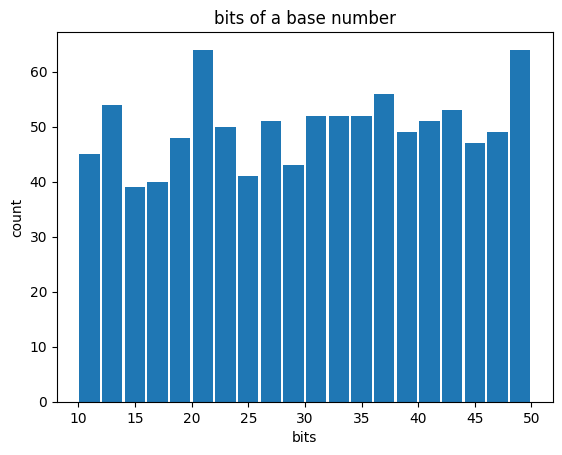

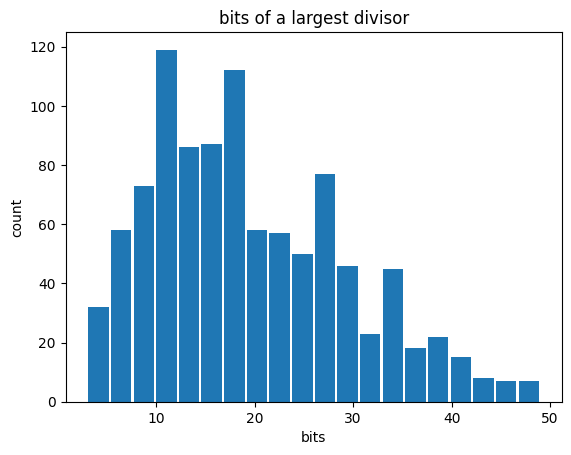

(array([ 32,  58,  73, 119,  86,  87, 112,  58,  57,  50,  77,  46,  23,
         45,  18,  22,  15,   8,   7,   7]),
 array([ 3. ,  5.3,  7.6,  9.9, 12.2, 14.5, 16.8, 19.1, 21.4, 23.7, 26. ,
        28.3, 30.6, 32.9, 35.2, 37.5, 39.8, 42.1, 44.4, 46.7, 49. ]))

In [14]:
def get_bins_counts(results, val_id = "n", title = "bits of a base number"):
    key = lambda r: r[val_id].bit_length()

    values = [key(r) for r in results]
    counts, bins = np.histogram(values, bins=20)
    plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
    plt.xlabel("bits")
    plt.ylabel("count")
    plt.title(title)
    plt.show()
    return counts, bins

counts, bins = get_bins_counts(results, "n")
get_bins_counts(results, "max_factor", "bits of a largest divisor")

Następnie grupujemy dane zależnie od rozmiaru faktoryzowanej liczby ...

In [15]:
def get_times_from_nonempty(results, val_id, bins):
    key = lambda r: r[val_id].bit_length()

    def group_by(data, key, bins):
        inds = np.digitize([key(r) for r in data], bins)
        data_bins = [[] for _ in bins]

        for i, idx in enumerate(inds):
            data_bins[idx - 1].append(data[i])

        return data_bins
    
    data_bins = group_by(results, key, bins)

    nonempty = [data for data in data_bins if data]
    mask = np.array([len(data) > 0 for data in data_bins])
    bins = bins[mask]

    def over_time(f, nonempty):
        return np.array([f([r["time"] for r in data]) for data in nonempty])
    
    times = over_time(np.mean, nonempty=nonempty)
    times_min = over_time(np.min, nonempty=nonempty)
    times_max = over_time(np.max, nonempty=nonempty)
    times_std = over_time(np.std, nonempty=nonempty)

    return bins, times, times_min, times_max, times_std

Intuicyjnie możemy oczekiwać, że czas faktoryzacji metodą trial division będzie proporcjonalny do $\sqrt{n}$.
Analizując złożoność algorytmów faktoryzacji operujemy raczej na rozmiarze liczby w bitach niż na jej wartości.
W tym kontekście zależność ta przekłada się na $T \sim 2^{B / 2}$, gdzie $T$ to czas, a $B$ to ilość bitów,
$B = \lceil \log_2 n\rceil$.

Innymi słowy, oczekujemy, że
$$
\log_2 T \approx \frac{1}{2} B + \beta
$$
Możemy zbadać tę hipotezę przy użyciu regresji liniowej zastosowanej do zebranych danych.

In [16]:
bins, times, times_min, times_max, times_std = get_times_from_nonempty(results, "n", bins)

def plot_estimate_and_times(bins, times, times_min, times_max, times_std):
    # Dla małych liczb czasy mogą być niezbyt miarodajne
    skip = 10

    T = times[skip:]
    B = bins[skip:]

    a, b = np.polyfit(B, np.log2(T), deg=1)

    estimate = 2 ** (a * bins + b)

    fig, ax = plt.subplots()
    ax.semilogy(bins, times, linewidth=2)
    ax.semilogy(bins, estimate, linestyle="--", color="black", linewidth=1)
    ax.fill_between(bins, times_min, times_max, alpha=0.1)
    # ax.fill_between(bins, times - times_std, times + times_std, alpha=0.1)
    ax.set_xlabel("bits")
    ax.set_ylabel("time [s]")
    ax.text(0.1, 0.9, rf"$T(n) \sim n^{{{a:.2f}}}$", transform=ax.transAxes, fontsize=12)
    plt.show()

Jeśli wszystko poszło dobrze, $a$ powinno być bliskie $1/2$.

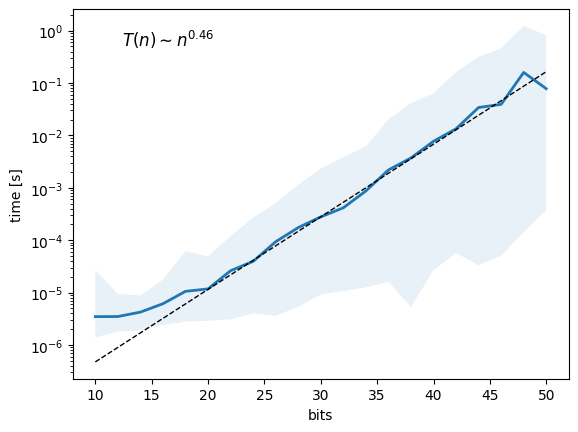

In [17]:
plot_estimate_and_times(bins, times, times_min, times_max, times_std)

### Zadanie 1

1. Jak wygląda zależność czasu faktoryzacji metodą trial division od rozmiaru największego czynnika pierwszego? Przedstaw ją na wykresie podobnym do powyższego. Która wielkość pozwala dokładniej przewidzieć czas faktoryzacji: rozmiar liczby, czy rozmiar jej największego czynnika pierwszego?
2. Wariant metody trial division jest często używany jako pierwszy krok bardziej złożonych metod. Zamiast próbować dzielić przez wszystkie liczby aż do $\lfloor \sqrt{n}\rfloor$, próbujemy wszystkich liczb pierwszych mniejszych, niż pewne zadane górne ograniczenie. Zaimplementuj funkcję realizującą taką częściową faktoryzację. Powinna ona przyjmować liczbę $n$ oraz górne ograniczenie na sprawdzane liczby pierwsze, a zwracać znalezioną częściową faktoryzację oraz niesfaktoryzowaną "resztę" która pozostała z $n$.

### Rozwiązanie 1.1

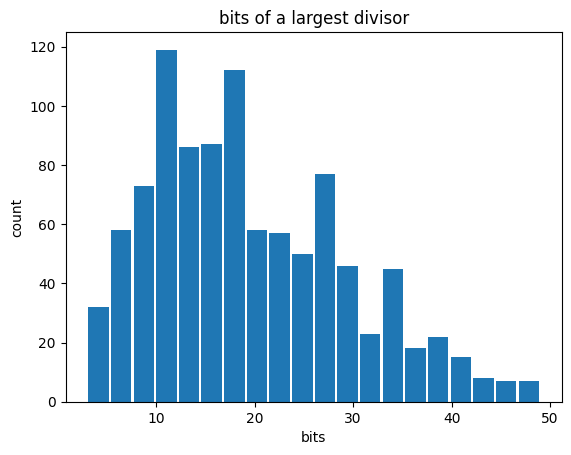

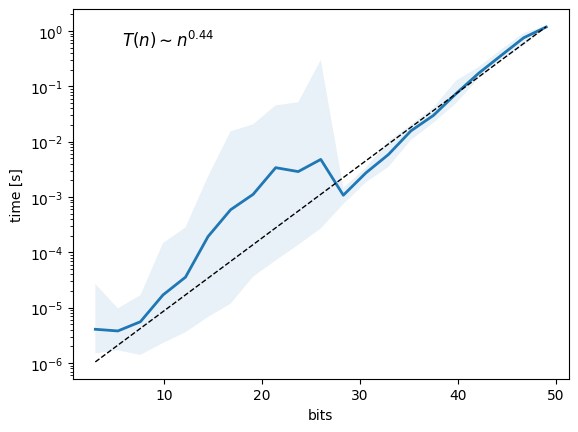

In [18]:
counts_fact, bins_fact = get_bins_counts(results, "max_factor", "bits of a largest divisor")
bins_fact, times_fact, times_fact_min, times_fact_max, times_fact_std = get_times_from_nonempty(results, "max_factor", bins_fact)
plot_estimate_and_times(bins_fact, times_fact, times_fact_min, times_fact_max, times_fact_std)

Wykres zależności czasu faktoryzacji od największego czynnika pierwszego wygląda podobnie do wykresu zależności czasu od faktoryzowanej liczby, ma przy estymacji trochę mniejszy wykładnik. Sądzę, że największy czynnik pierwszy pozwala dokładniej oszacować czas faktoryzacji

### Rozwiązanie 1.2

In [19]:
def factor_out_small_primes(n, upto=1000) -> tuple[Counter, int]:
    """
    >>> factor_out_small_primes(20020, upto=7)
    (Counter({2: 2, 5: 1, 7: 1}), 143)
    """
    ...
    m = n
    factors = Counter()
    count = 0
    while m % 2 == 0:
        m, count = m//2, count + 1

    if count > 0:
        factors[2] = count
    
    for i in range(3, min(np.ceil(np.sqrt(n)), upto + 1), 2): # only odd numbers
        count = 0
        while m % i == 0:
            m, count = m//i, count + 1
        if count > 0:
            factors[i] = count
    return factors, m

In [20]:
factor_out_small_primes(20020, upto=7)

(Counter({2: 2, 5: 1, 7: 1}), 143)

## Sito kołowe (wheel factorization)

Sito kołowe to optymalizacja metody dzielenia próbnego poprzez pomijanie niektórych liczb. Przykładowo, jeśli sprawdziliśmy, czy nasza liczba jest podzielna przez $2$, możemy pominąć w dalszych testach wszystkie liczby parzyste. Możemy zatem w pętli zwiększać licznik o $2$ zamiast o $1$, zmniejszając ilość testów o połowę. Sito kołowe to uogólnienie tego pomysłu polegające na pomijaniu wielokrotności pierwszych $k$ liczb pierwszych.

Działanie sita kołowego najłatwiej pokazać na niewielkim, konkretnym przykładzie. Załóżmy, że chcemy pomijać w testach wszystkie wielokrotności liczb $2$, $3$ i $5$. O tym, czy liczba jest podzielna przez którąś z nich, decyduje reszta z dzielenia przez $2 \times 3 \times 5 = 30$. Niepodzielne przez $2$, $3$ i $5$ są dokładnie te liczby, których reszta z dzielenia przez $30$ nie jest podzielna przez żadną z tych liczb, tzn. jest zawarta w
$$
1, 7, 11, 13, 17, 19, 23, 29
$$
By wydajnie generować takie liczby, zaczniemy od $7$ i będziemy poruszać się do przodu o kolejne odstępy pomiędzy tymi resztami:
$$
\underbrace{4}_{11 - 7}, \underbrace{2}_{13 - 11}, \underbrace{4}_{17 - 13}, \underbrace{2}_{19 - 17},
\underbrace{4}_{23 - 19}, \underbrace{6}_{29 - 23}, \underbrace{2}_{1 - 29 \bmod{30}}, \underbrace{6}_{7 - 1}, \ldots
$$
Gdy dochodzimy do końca tablicy odstępów, zapętlamy się. Generacja ciągu wygląda następująco:
$$
7 \xrightarrow{+4}
11 \xrightarrow{+2}
13 \xrightarrow{+4}
17 \xrightarrow{+2}
19 \xrightarrow{+4}
23 \xrightarrow{+6}
29 \xrightarrow{+2}
31 \xrightarrow{+6}
37 \xrightarrow{+4}
41 \xrightarrow{+2}
43 \xrightarrow{+4}
47 \xrightarrow{+2}
49 \xrightarrow{+4}
53 \xrightarrow{+6}
59 \xrightarrow{+2}
61 \xrightarrow{+6}
67 \xrightarrow{+4}
71 \xrightarrow{+2}
73 \xrightarrow{+4} \ldots
$$

By sfaktoryzować liczbę $n$ metodą sita kołowego:
- generujemy tablicę odstępów dla liczb pierwszych $p_1,\ldots,p_k$ (można to zrobić raz i reużywać ją do wielu faktoryzacji)
- sprawdzamy, czy $n$ jest podzielna przez $p_1,\ldots,p_k$
- przy pomocy tablicy odstępów generujemy ciąg potencjalnych dzielników i wykonujemy dzielenie próbne

### Zadanie 2

1. Zaimplementuj sito kołowe i przetestuj poprawność jego działania.
2. Jaki zysk w praktyce daje sito kołowe w zależności od ilości użytych liczb pierwszych? Przetestuj zyski na liczbach $\leq 10^6$ (można użyć funkcji `measure_time`). Narysuj wykres przyspieszenia w stosunku do bazowej metody trial division (na osi $X$ ilość użytych do sita liczb pierwszych, na osi $Y$ czas zwykłego trial division podzielony przez czas wersji z sitem).
3. Jak rosną czas i pamięć potrzebne do zbudowania sita kołowego wraz z ilością użytych liczb pierwszych?
4. (**dodatkowe**) "Idealne" (nieskończone) sito kołowe sprawdzałoby wyłącznie podzielność przez liczby pierwsze. Jakie przyspieszenie pozwoliłoby to osiągnąć dla liczb $\leq 10^6$? (lista `PRIMES` zawiera wszystkie liczby pierwsze potrzebne do testu). Jak zmieniałoby się to przyspieszenie wraz z rozmiarem faktoryzowanych liczb? (**[HINT](https://en.wikipedia.org/wiki/Prime_number_theorem)**)

### Rozwiązanie 2.1

In [ ]:
def generate_array_of_jumps(prod, primes):
    primes.sort()
    prod += 2 # we want to get to another 1 to close the cycle
    is_div = [False for _ in range(prod)]

    for p in primes:
        for j in range(p, prod, p):
            is_div[j] = True

    prev_num, idx, steps = 1, 2, []

    # while prev_num < prod and is_div[prev_num]:
    #     prev_num += 1

    while idx < prod:
        if not is_div[idx]:
            steps.append(idx - prev_num)
            prev_num = idx
        idx += 1
    return 1, steps


def factorize_known(N, primes, prev_factors):
    for p in primes:
        count = 0
        while N % p == 0:
            N, count = N//p, count + 1
        if count > 0:
            prev_factors[p] = count
        if N == 1:
            break
    return N
    

def wheel_sieve(n, primes, prev_factors=Counter()):
    mod = 1
    for p in primes:
        mod *= p

    n = factorize_known(n, primes, prev_factors)
    if n == 1:
        return
    
    _, steps = generate_array_of_jumps(mod, primes)
    cycle_pos, num = 1, 1 + steps[0] 
    cycle_len = len(steps)

    while num * num <= n:
        count = 0
        while n % num == 0:
            n, count = n//num, count + 1
        if count > 0:
            prev_factors[num] = count
            
        num += steps[cycle_pos]
        cycle_pos = (cycle_pos + 1) % cycle_len

    if n > 1:
        prev_factors[n] += 1
    return

factors1 = Counter()
wheel_sieve(63, [2, 3, 5], factors1)
check_factorization(63, factors1)

True

In [22]:
factors2 = Counter()
N = 12345678
wheel_sieve(N, PRIMES[:7], factors2)
print(factors2)
print(check_factorization(N, factors2))

Counter({3: 2, 2: 1, 47: 1, 14593: 1})
True


## Metoda $\rho$ Pollarda

Niech $n$ będzie liczbą, którą chcemy sfaktoryzować, zaś $p$ jej czynnikiem pierwszym.
Jeśli $x, y \in \mathbb{Z} / n\mathbb{Z}$ spełniają $x \equiv y \pmod p$, to największy wspólny dzielnik $d = (x - y, n)$ jest dzielnikiem $n$ podzielnym przez $p$.
Jeśli $d \neq n$, to $d$ jest nietrywialnym dzielnikiem $n$.
Jeśli potrafimy zatem znaleźć takie $x$ i $y$, to jest duża szansa, że uda się w ten sposób rozłożyć $n$.
Wybierając losowe liczby z $\{1,\ldots,n\}$ mamy sporą szansę na znalezienie ich wśród pierwszych $\sim \sqrt{p}$ liczb,
ale sprawdzeneie wszystkich par kosztowałoby $\mathcal{O}(p)$ - tak samo jak metoda próbnego dzielenia.
Musimy więc zrobić to sprytniej.

W metodzie $\rho$ Pollarda wybieramy pewną funkcję wielomianową $f$, zazwyczaj postaci $f(x) = x^2 + b$.
Możemy ją interpretować jako funkcję $f\colon \mathbb{Z}/n\mathbb{Z} \to \mathbb{Z}/n\mathbb{Z}$ biorąc jej wartości modulo $n$.
Przy jej pomocy generujemy ciąg elementów $x_1,x_2,\ldots$ tak, że $x_{k+1} = f(x_k)$.
Ciąg $\{x_k\}$ modulo $n$ indukuje ciąg $\bar{x}_k = x_k \bmod p$.
Dzięki temu, że $f$ jest wielomianem, mamy również $\bar{x}_{k+1} = f(\bar{x}_k) \bmod p$.
Dzięki temu, że $\bar{x}_k$ jest generowany poprzez iteracje funkcji,
po pewnej liczbie iteracji musi wpaść w cykl, tzn. istnieje $k \geq 1$ takie, że $\bar{x}_{i + mk} = \bar{x}_i$ dla odpowiednio dużego $i$ i dowolnego $m \geq 0$.
Wówczas $x_{i+mk} \equiv x_i \pmod p$ i jeśli $x_{i+mk} \not\equiv x_i \pmod n$, to $(x_{i+mk} - x_i, n)$ będzie nietrywialnym dzielnikiem $n$.
By znaleźć taki cykl, możemy użyć znanego z WDI / ASD algorytmu żółwia i zająca
(dwa wskaźniki, jeden skacze o $1$ węzeł, drugi o $2$, jeśli istnieje cykl to w końcu się spotkają).

#### Algorytm

1. Wylosuj $1 \leq b \leq n - 3$, wówczas $f(x) = x^2 + b$.
2. Wylosuj $0 \leq x < n$.
3. $y \gets x$
4. Dopóki nie przerwiemy:
   - $x \gets f(x)$
   - $y \gets f(f(y))$
   - $d \gets (x - y, n)$
   - jeśli $d = n$, przerwij algorytm i zasygnalizuj porażkę
   - jesli $d \neq 1$, zwróć $d$ jako nietrywialny dzielnik $n$

Możemy zrobić kilka iteracji dla różnych wartości $x$ i $b$ by zwiększyć szansę na odnalezienie czynnika.
Jeśli wykonujemy tylko jedną iterację, możemy użyć standardowych wartości $x = 2$, $b = 1$.

Należy pamiętać, że metoda $\rho$ Pollarda znajdzie **dzielnik** faktoryzowanej liczby - niekoniecznie będzie to liczba pierwsza. Szukając rozkładu na czynniki pierwsze musimy sprawdzić, czy otrzymane dzielniki są liczbami pierwszymi, i w razie potrzeby je sfaktoryzować.

**Uwaga** Nie ma gwarancji, że metoda $\rho$ Pollarda będzie w stanie znaleźć czynnik. Dla niektórych liczb algorytm nie działa (np. dla $4$). Po pewnej liczbie iteracji nie pozostaje nam nic innego, jak się poddać i przekazać pałeczkę innemu algorytmowi faktoryzacji, np. trial division.

#### Sugestie wydajnościowe
- Najlepiej zacząć od sprawdzenia podzielności przez małe liczby pierwsze. Można w tym celu wykorzystać metodę `factor_out_small_primes` z Zadania 1.
- Przed faktoryzacją opłaca się sprawdzić, czy przypadkiem liczba nie jest pierwsza, używając wydajnego testu probabilistycznego.

### Zadanie 3

1. Zaimplementuj metodę $\rho$ Pollarda.
2. Jak zależy jej wydajność od następujących wielkości? Która z nich ma największy wpływ na czas działania? Przeprowadź testy na losowych liczbach o rozmiarze 40-100 bitów i przedstaw wyniki na odpowiednich wykresach.
   - rozmiar faktoryzowanej liczby
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
3. Jak wygląda wydajność metody $\rho$ Pollarda w porównaniu z metodą próbnego dzielenia? Przedstaw zależność czasu faktoryzacji od rozmiaru liczby na jednym wykresie.
4. (**dodatkowe**) Przy użyciu wydajnej metody faktoryzacji możemy dowiedzieć się czegoś na temat właściwości statystycznych dużych liczb. Jak wyglądają rozkłady następujących wielkości dla liczb np. 80-bitowych? Narysuj odpowiednie histogramy.
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
   - rozmiar najmniejszego czynnika pierwszego
   - ilość unikalnych czynników pierwszych
   - najwyższa potęga występująca w rozkładzie
5. (**dodatkowe**) Istnieje alternatywny, bardziej wydajny sposób znajdowania cykli: **[algorytm Brenta](https://en.wikipedia.org/wiki/Cycle_detection#Brent.27s_algorithm)**. Zmodyfikuj implementację faktoryzacji $\rho$ Pollarda tak, by znajdował cykle z wykorzystaniem tej metody. Porównaj wydajność obu rozwiązań.

## Pollard $p-1$

**Małe Twierdzenie Fermata**. Jeśli $p$ jest liczbą pierwszą i $a$ nie jest podzielne przez $p$, to $a^{p-1} \equiv 1 \pmod p$.

Zasada działania metody $p - 1$ Pollarda jest następująca. Niech $n$ będzie liczbą, którą chcemy sfaktoryzować, a $p$ będzie jednym z jej czynników pierwszych.
Jeśli $M$ jest liczbą podzielną przez $p - 1$, tzn. $M = L(p - 1)$ dla pewnego $L$, to z Małego Twierdzenia Fermata mamy
$$
a^M \equiv a^{L(p-1)} \equiv (a^{p-1})^L \equiv 1^L \equiv 1 \pmod p
$$
tzn. $a^M - 1$ jest podzielne przez $p$.
Skoro $n$ również jest podzielne przez $p$, to ich największy wspólny dzielnik $d = (a^M - 1, n)$ również jest podzielny przez $p$.
Jeśli $d \neq n$, to odnieśliśmy sukces, $d$ jest nietrywialnym dzielnikiem $n$.

Istotą metody $p - 1$ Pollarda jest sposób szukania odpowiedniej liczby $M$.
Wybierzmy dowolną liczbę $B$.
Załóżmy, że $n$ posiada czynnik pierwszy $p$ taki, że rozkład $p - 1 = q_1^{a_1} \ldots q_k^{a_k}$ na czynniki pierwsze spełnia warunek $q_i^{a_i} \leq B$
(mówimy wówczas, że $p - 1$ jest $B$-powersmooth). Niech $M = \operatorname{lcm}\{1,2,\ldots,B\}$.
Przy powyższym założeniu takie $M$ z pewnością jest podzielne przez $p - 1$,
a zatem na mocy wcześniej pokazanego rozumowania, $(a^M - 1, n)$ jest dzielnikiem $n$.
Skoro ostatecznie interesuje nas największy wspólny dzielnik $a^M - 1$ i $n$, wystarczy obliczyć $a^M \bmod n$.

Wartość $M$ możemy obliczyć jako iloczyn wszystkich liczb pierwszych $q \leq B$ podniesionych do największej możliwej potęgi $a$ takiej, że $q^a \leq B$:
$$
M = \prod_{q \leq B,\ q \text{ prime}} q^{\lfloor \log_q B \rfloor}
$$
Możemy myśleć o $M$ jako o największej możliwej liczbie $B$-powersmooth.
Nie musimy obliczać i przechowywać $M$ w całości - by policzyć $a^M \bmod n$ wystarczy zacząć od $a$
i podnosić je do potęg $q^{\lfloor \log_q B \rfloor}$ dla kolejnych liczb pierwszych $q$.
Nie musimy również sprawdzać, czy $(a^M - 1, n)$ jest nietrywialnym dzielnikiem $n$ wyłącznie raz na samym końcu.
Zamiast tego, możemy co pewną liczbę iteracji (np. co 100 liczb pierwszych) sprawdzać, czy częściowy wynik daje nam dzielnik $n$.
Im częściej wykonamy takie sprawdzenie, tym większy będzie koszt obliczeniowy,
ale i tym większa szansa, że "złapiemy" dzielnik zanim $(a^M - 1, n)$ stanie się całym $n$.

#### Algorytm

Wejście: liczba $n$ do sfaktoryzowania, $B$ - parametr

1. wylosuj $2 \leq a \leq n - 1$
2. dla liczb pierwszych $q \leq B$:
   - $f \gets q^{\lfloor \log_q B \rfloor}$
   - $a \gets a^f \pmod n$
   - co ileś iteracji:
     - $d \gets (a - 1, n)$
     - jeśli $d \not\in \{1, n\}$, zwróć $d$ jako nietrywialny dzielnik $n$
     - jeśli $d = n$, przerwij algorytm i zasygnalizuj porażkę

Możemy zrobić kilka iteracji dla różnych wartości $a$ by zwiększyć szansę na odnalezienie czynnika.
Jeśli jednak dla żadnego czynnika pierwszego $p$ liczba $p - 1$ nie jest $B$-powersmooth, algorytm nie ma szans zadziałać.
Można wówczas spróbować zwiększyć wartość parametru $B$, ale dla pewnych liczb nawet to nie zadziała.
Podobnie jak w przypadku metody $\rho$ Pollarda, nie ma gwarancji że metoda $p-1$ Pollarda znajdzie czynnik faktoryzowanej liczby.
Należy dodać jakąś inną metodę jako fallback.

Metoda $p - 1$ Pollarda znajdzie **dzielnik** faktoryzowanej liczby - niekoniecznie będzie to liczba pierwsza. Szukając rozkładu na czynniki pierwsze musimy sprawdzić, czy otrzymane dzielniki są liczbami pierwszymi, i w razie potrzeby je sfaktoryzować.

Odnośnie wydajności - te same sugestie co do metody $\rho$ Pollarda.

### Zadanie 4

1. Zaimplementuj metodę $p - 1$ Pollarda.
2. Jak zależy jej wydajność od następujących wielkości? Przeprowadź wymagane testy i przedstaw wyniki na odpowiednich wykresach.
   - rozmiar faktoryzowanej liczby
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
   - wartość parametru $B$
3. Jak wypada jej wydajność w porównaniu z metodą $\rho$ Pollarda dla losowych liczb?
4. Porównaj wydajność metod $p-1$ i $\rho$ Pollarda dla liczby $393153263702980669137355399246611499921$. Co jest przyczyną otrzymanego wyniku?
5. (**dodatkowe**) Jak wartość parametru $B$ wpływa na ilość sukcesów (tj. liczb, dla których metoda $p-1$ odnalazła czynnik)? Przedstaw zależność na wykresie.
6. (**dodatkowe**) Spróbuj sfaktoryzować obiema metodami liczbę Fermata $F_{12} = 2^{2^{12}} + 1$. Czy któraś metoda jest w stanie znaleźć jakieś czynniki pierwsze? Nie uda się sfaktoryzować $F_{12}$ w całości, więc może być konieczna modyfikacja kodu tak, by zwracał/wypisywał czynniki na bieżąco.
7. (**dodatkowe$^2$**) Metoda $p - 1$ Pollarda jest przykładem algorytmu z rodziny metod **[opartych o grupy algebraiczne](https://en.wikipedia.org/wiki/Algebraic-group_factorisation_algorithm)**. Inną metodą tego typu jest faktoryzacja przy użyciu krzywych eliptycznych. Poszukaj informacji na jej temat, zaimplementuj ją i porównaj wydajność z innymi metodami z ćwiczeń.

## Metoda Fermata

Jeśli potrafimy wyrazić $n$ jako różnicę kwadratów: $n = x^2 - y^2$, to $x \pm y$ są dzielnikami $n$, jako że
$$
n = x^2 - y^2 = (x + y)(x - y)
$$
Metoda Fermata polega na poszukiwaniu $x$, $y$ o tej własności.
Zaczynamy z $x = \lceil \sqrt{n} \rceil$.
W kolejnych iteracjach zwiększamy $x$ co $1$ i sprawdzamy, czy $y^2 = x^2 - n$ jest pełnym kwadratem (czy $y$ jest liczbą całkowitą).

W implementacji może przydać się funkcja **[math.isqrt](https://docs.python.org/3/library/math.html#math.isqrt)**.

### Zadanie 5

1. Zaimplementuj metodę Fermata
2. Przetestuj zyski na liczbach $\leq 10^6$. Jak wypada porównanie z pozostałymi metodami? Czy metoda Fermata jest użyteczna jako metoda faktoryzacji ogólnego przeznaczenia?

### Rozwiązanie zadań 3 i 4

In [30]:
def gcd(a, b):
    a, b = abs(a), abs(b)
    while b != 0:
        a, b = b, a % b
    return a


def get_primes_upto(B):
    idx = 0
    while PRIMES[idx] <= B:
        idx += 1
    return PRIMES[:idx]


def p_pollard(n, max_iter=10000):
    b = random.randint(1, n-3)
    func = lambda x: ((x * x) % n + b) % n
    x = random.randint(0, n) # pointer moving by 1
    y = x # pointer moving by 2

    for _ in range(max_iter):
        x = func(x)
        y = func(func(y))
        d = gcd(x - y, n)
        if d == n:
            return False, None
        if d != 1:
            return True, d
        
    return False, -1
        

def execute_rho_pollard(n, num_trials=20):
    for _ in range(num_trials):
        success, factor = p_pollard(n)
        if success:
            return factor
    return None

In [31]:
def p_minus_pollard(n, B, max_iter = 10):
    for _ in range(max_iter):
        a = random.randint(2, n-1)
        failed = False
        for i, prime in enumerate(get_primes_upto(B)):
            exp = prime
            while exp * prime <= B:
                exp *= prime
                
            a = fast_power_mod_iter(a, exp, n)

            if i % 20 == 0:
                d = gcd((a - 1) % n, n)
                if 1 < d < n:
                    return True, d
                if d == n:
                    failed = True
                    break
        
        if failed:
            continue

        d = gcd((a - 1) % n, n)
        if 1 < d < n:
            return True, d
        
    return False, None


def execute_p_minus_pollard_random(n, choices, lb, ub):
    for _ in range(choices):
        B = random.randint(lb, ub)
        success, factor = p_minus_pollard(n, B)
        if success:
            return factor
    return None


def execute_p_minus_pollard_given(n, Bs):
    for B in Bs:
        success, factor = p_minus_pollard(n, B)
        if success:
            return factor
    return None

In [75]:
def factorize_general(n, use_p, use_rho):
    if n <= MAX_N and isprime(n):
        return Counter({n: 1})
    factors = Counter()
    if n <= 10**10:
        first_primes = PRIMES[:6]
        wheel_sieve(n, first_primes, factors)
        return factors
    
    factor = execute_p_minus_pollard_random(n, 100, 5000, 10000) if use_p else None
    if factor is not None:
        # print(f"Found factor {factor} using Pollard's p-1")
        pass
    if factor is None:
        if not use_rho:
            return None
        # print(f"Pollard's p-1 failed for {n}, trying Pollard's rho")
        factor = execute_rho_pollard(n)
        if factor is not None:
            # print(f"Found factor {factor} using Pollard's rho")
            pass
        if factor is None:
            return None
        
    n //= factor
    if isprime(factor):
        factors[factor] += 1
    else:
        factors += factorize_general(factor, use_p, use_rho)
    
    recursive_factor = factorize_general(n, use_p, use_rho)

    if recursive_factor is not None:
        factors += recursive_factor
        return factors
    
    return None

In [76]:
x = 12345678
print(execute_p_minus_pollard_random(12345678, 100, 1000, 10000))
print(execute_rho_pollard(12345678))

2
6


In [77]:
def test_factorization_random(num_tests=100, bits=60, print_factors=False, use_p = True, use_rho = True):
    successes = 0

    for _ in range(num_tests):
        y = random.getrandbits(bits)
        y_fact = factorize_general(y, use_rho, use_p)
        if print_factors:
            print(y_fact)
        if y_fact is not None:
            successes += 1
            assert check_factorization(y, y_fact)

    print(f"Success rate: {successes}/{num_tests}")
    return math.floor(successes / num_tests * 100)


def test_factorization_specific(numbers, print_factors=False, use_p = True, use_rho = True):
    successes = 0
    for n in numbers:
        factors = factorize_general(n, use_p, use_rho)
        if print_factors:
            print(f"Factors of {n}: {factors}")
        if factors is not None:
            assert check_factorization(n, factors)
            successes += 1

    print(f"Success rate: {successes}/{len(numbers)}")
    return math.floor(successes / len(numbers) * 100)


In [78]:
def generate_successes_rates_per_size(sizes, use_p, use_rho):
    if sizes is None:
        sizes = np.arange(40, 80+1, 10)
    res_per_size = []
    for n in sizes:
        print(n, end = ' ')
        res_per_size.append(test_factorization_random(num_tests=10, bits=60, print_factors=False, use_p = use_p, use_rho = use_rho))
        
    return sizes, res_per_size



def prepare_prime_factors(bits = 40, num = 10):
    big_primes = []
    for _ in range(num):
        p = random.getrandbits(bits)
        while not isprime(p):
            p = random.getrandbits(bits)
        big_primes.append(p)
    
    return big_primes
    

def generate_successes_rates_per_greatest_prime_in_bits(sizes_p, size_q, use_p, use_rho):
    q = random.getrandbits(size_q) # q will be constant, we want to see how the size of p affects the success rate
    res_per_size = []
    for size_p in sizes_p:
        print(size_p, end=' ')
        Ps = prepare_prime_factors(size_p, num=10) # 10 primes of given size in bits
        nums = []
        for p in Ps:
            n = p * q
            nums.append(n)
        res = test_factorization_specific(nums, print_factors=False, use_p = use_p, use_rho=use_rho)
        res_per_size.append(res)

    return sizes_p, res_per_size


def generate_per_second_greatest_prime(size_p, sizes_q, use_p, use_rho):
    assert size_p > max(sizes_q)
    p = random.getrandbits(size_p)
    while not isprime(p):
        p = random.getrandbits(size_p)

    res_per_size = []
    for size_q in sizes_q:
        print(size_q, end=' ')
        Qs = prepare_prime_factors(size_q, num=10)
        nums = []
        for q in Qs:
            n = p * q
            nums.append(n)
        res = test_factorization_specific(nums, print_factors=False, use_p = use_p, use_rho=use_rho)
        res_per_size.append(res)

    return sizes_q, res_per_size



In [99]:
x, y = generate_successes_rates_per_size([i for i in range(40, 101, 5)], True, True)
print(x, y)

40 Success rate: 8/10
45 Success rate: 5/10
50 Success rate: 5/10
55 Success rate: 4/10
60 Success rate: 4/10
65 Success rate: 4/10
70 Success rate: 4/10
75 Success rate: 4/10
80 Success rate: 4/10
85 Success rate: 5/10
90 Success rate: 4/10
95 Success rate: 4/10
100 Success rate: 2/10
[40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100] [80, 50, 50, 40, 40, 40, 40, 40, 40, 50, 40, 40, 20]


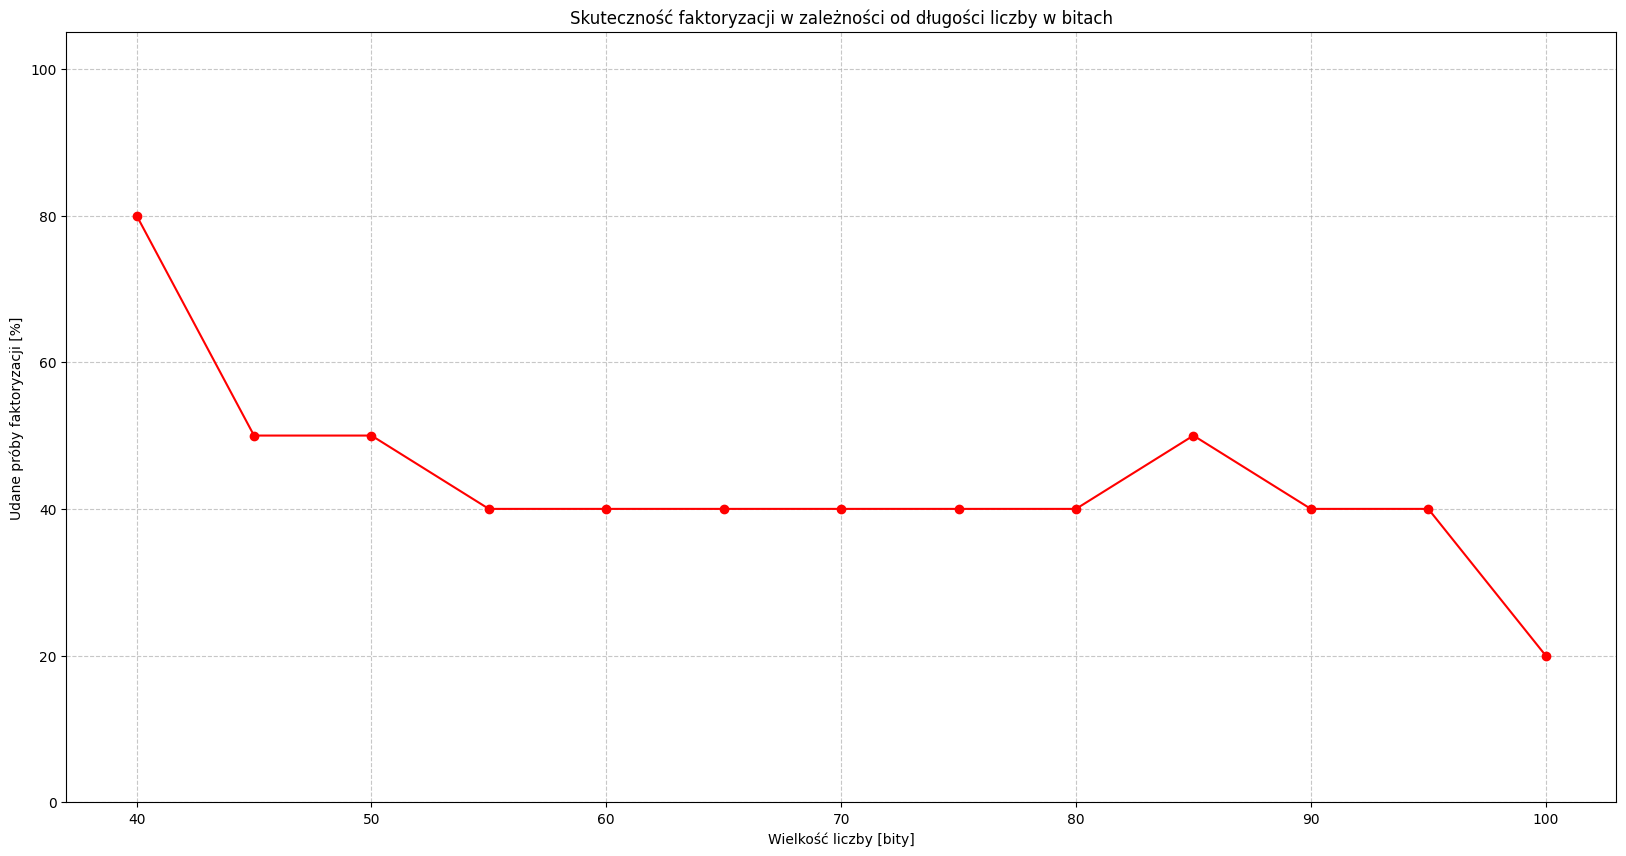

In [101]:
plt.figure(figsize=(20, 10))
plt.plot(x, y, color = "red", marker='o', linestyle='-')

plt.xlabel('Wielkość liczby [bity]')
plt.ylabel('Udane próby faktoryzacji [%]')
plt.title('Skuteczność faktoryzacji w zależności od długości liczby w bitach')

plt.ylim(0, 105)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [79]:
x1, y1 = generate_successes_rates_per_greatest_prime_in_bits([i for i in range(16, 45)], 15, True, True)

16 Success rate: 10/10
17 Success rate: 10/10
18 Success rate: 10/10
19 Success rate: 10/10
20 Success rate: 10/10
21 Success rate: 10/10
22 Success rate: 10/10
23 Success rate: 10/10
24 Success rate: 10/10
25 Success rate: 10/10
26 Success rate: 10/10
27 Success rate: 10/10
28 Success rate: 10/10
29 Success rate: 10/10
30 Success rate: 10/10
31 Success rate: 10/10
32 Success rate: 10/10
33 Success rate: 10/10
34 Success rate: 7/10
35 Success rate: 4/10
36 Success rate: 3/10
37 Success rate: 0/10
38 Success rate: 0/10
39 Success rate: 0/10
40 Success rate: 0/10
41 Success rate: 0/10
42 Success rate: 0/10
43 Success rate: 0/10
44 Success rate: 0/10


In [80]:
print(x1, y1)

[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44] [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 70, 40, 30, 0, 0, 0, 0, 0, 0, 0, 0]


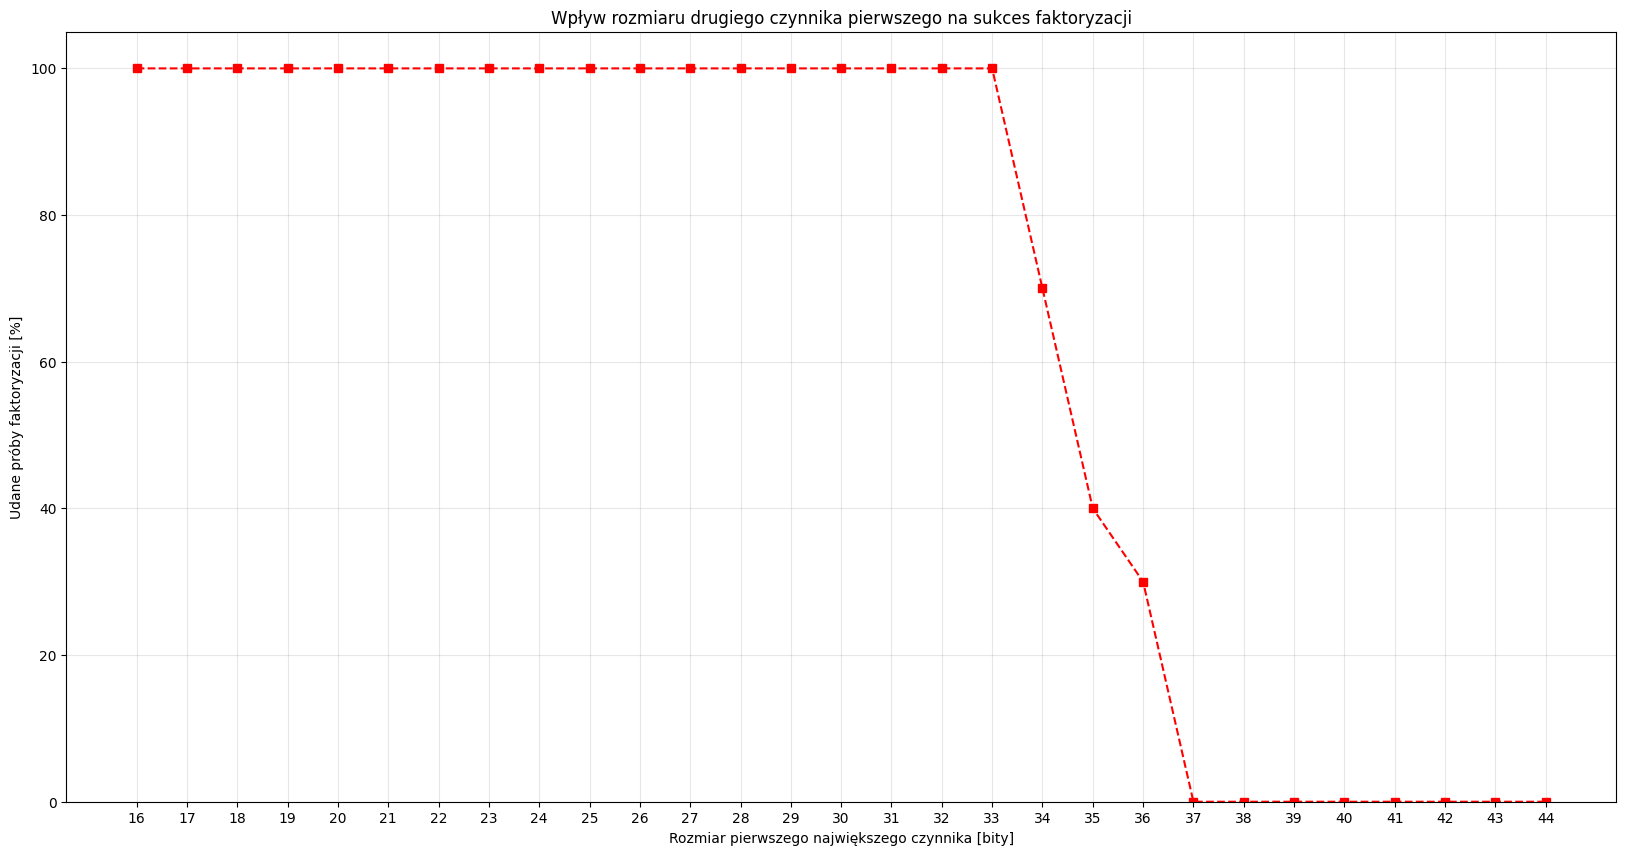

In [95]:
plt.figure(figsize=(20, 10))
plt.plot(x1, y1, marker='s', color='red', linestyle='--')
plt.xticks(x1)
plt.xlabel('Rozmiar pierwszego największego czynnika [bity]')
plt.ylabel('Udane próby faktoryzacji [%]')

plt.title('Wpływ rozmiaru drugiego czynnika pierwszego na sukces faktoryzacji')

plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

plt.show()

In [93]:
x2, y2 = generate_per_second_greatest_prime(30, [i for i in range(15, 30)], True, True)

15 Success rate: 10/10
16 Success rate: 10/10
17 Success rate: 10/10
18 Success rate: 10/10
19 Success rate: 10/10
20 Success rate: 10/10
21 Success rate: 10/10
22 Success rate: 10/10
23 Success rate: 10/10
24 Success rate: 10/10
25 Success rate: 10/10
26 Success rate: 10/10
27 Success rate: 10/10
28 Success rate: 10/10
29 Success rate: 10/10


In [86]:
print(x2, y2)

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 90, 60]


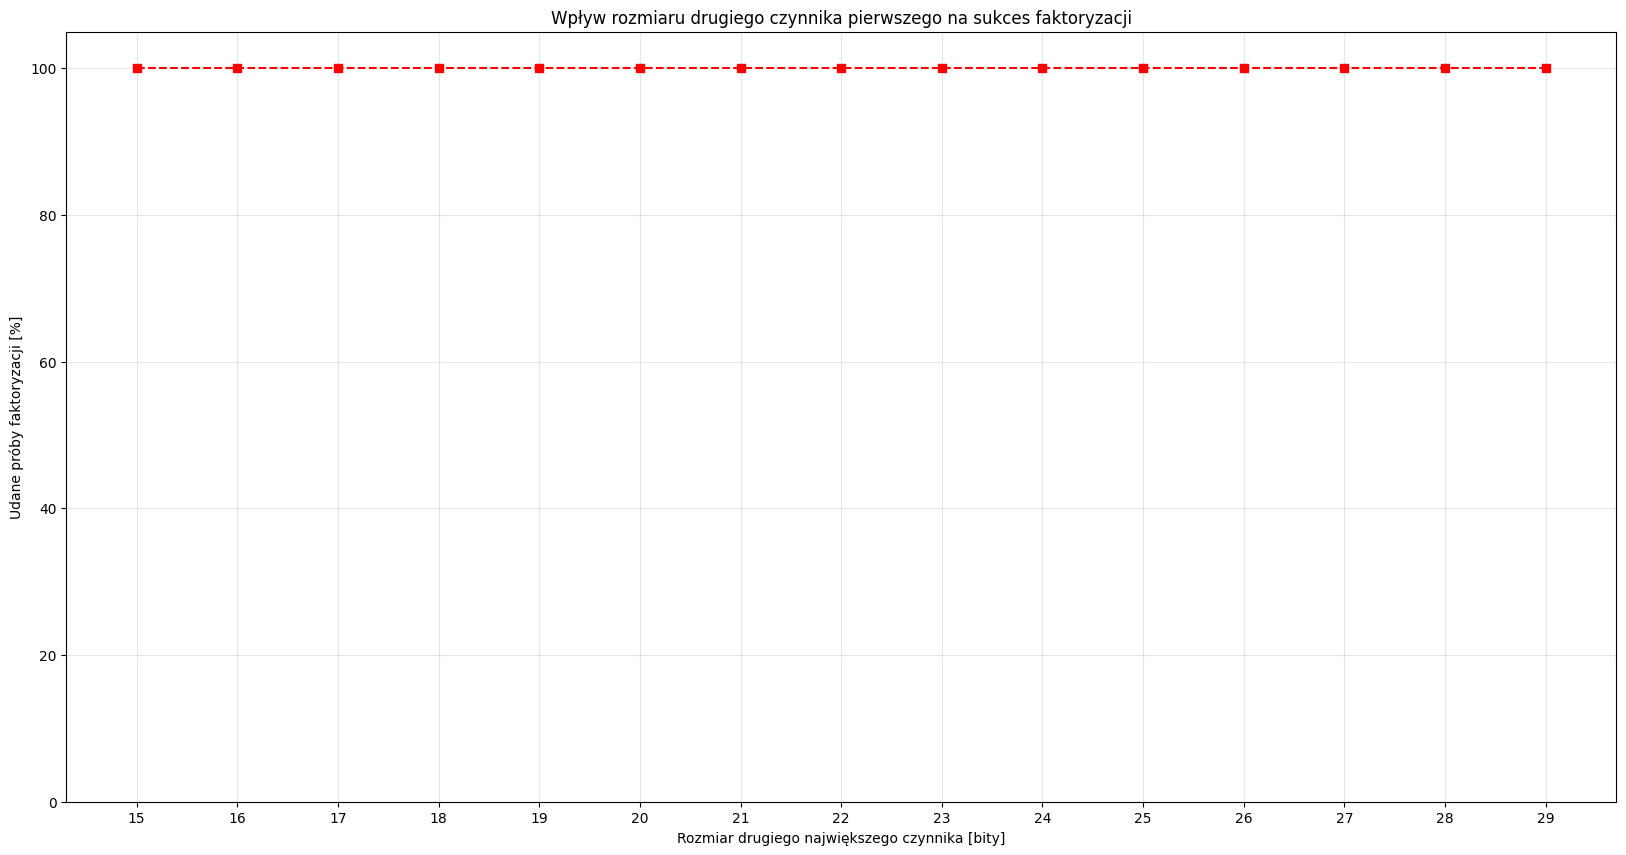

In [98]:
plt.figure(figsize=(20, 10))
plt.plot(x2, y2, marker='s', color='red', linestyle='--')

plt.xticks(x2)
plt.xlabel('Rozmiar drugiego największego czynnika [bity]')
plt.ylabel('Udane próby faktoryzacji [%]')

plt.title('Wpływ rozmiaru drugiego czynnika pierwszego na sukces faktoryzacji')

plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

plt.show()

In [ ]:
test_number = 393153263702980669137355399246611499921
print(isprime(test_number))
print(execute_p_minus_pollard_random(test_number, 100, 10000, 100000))
execute_p_minus_pollard_given(test_number, [100000, 1000000])
print(execute_rho_pollard(test_number))

False


None
None


### Rozwiązanie zadania 5

In [ ]:
def fermat_method(n, iter_sqrt_limit=False, max_iter=10**7):
    res_counter = Counter()
    n = factorize_known(n, [2, 3, 5, 7, 11], res_counter)
    if n == 1:
        return res_counter
    if isprime(n):
        return res_counter + Counter({n:1})
    
    x = math.ceil(math.sqrt(n))
    max_x = math.isqrt(2*n) if iter_sqrt_limit else (n-1)//2 + 1
    max_x = min(max_x, x + max_iter)
    while x < max_x:
        x2 = x * x
        y2 = x2 - n
        y = math.isqrt(y2)
        if y ** 2 == y2:
            d1, d2 = x + y, x - y
            if d2 == 1:
                if isprime(d1):
                    res_counter[d1] += 1
                    return res_counter
                x += 1
                continue

            for d in [d1, d2]:
                if isprime(d):
                    res_counter[d] += 1
                else:
                    recursive_res = fermat_method(d)
                    if recursive_res is not None:
                        res_counter += recursive_res
                    else:
                        return None
            return res_counter
        x += 1

print(fermat_method(153))
print(fermat_method(26))



Counter({3: 2, 17: 1})
Counter({2: 1, 13: 1})


In [ ]:
def execute_wheel_sieve(n, primes):
    factors = Counter()
    time_start = time.time()
    wheel_sieve(n, primes, factors)
    assert check_factorization(n, factors)
    return factors, time.time() - time_start

def compare_fermat_and_wheel(lb = 30, ub = 40, no = 100, max_iter = 10**7):
    test_nums = [random.getrandbits(random.randint(lb, ub)) for _ in range(no)]
    times_fermat, times_wheel = [None for _ in range(no)], [None for _ in range(no)]
    success_fermat = 0

    for i, number in enumerate(test_nums):
        print(i, end = ' ')
        time_start = time.time()
        res = fermat_method(number, iter_sqrt_limit=False, max_iter=max_iter) # worst case linear complexity
        if res is not None:
            success_fermat += 1
            assert check_factorization(number, res)
            time_fermat = time.time() - time_start

        time_fermat = time.time() - time_start
        _, time_wheel = execute_wheel_sieve(number, PRIMES[:4])

        if res is not None:
            times_fermat[i] = round(time_fermat, 4)
        times_wheel[i] = round(time_wheel, 4)

        print("Fermat: ", times_fermat[i], ", Wheel:", times_wheel[i])

    return test_nums, success_fermat, times_fermat, times_wheel
        

In [ ]:
no = 100
test_nums, success_fermat, times_fermat, times_wheel = compare_fermat_and_wheel(lb=30, ub=30, no=no, max_iter=10**6)

0 Fermat:  0.0305 , Wheel: 0.0002
1 Fermat:  None , Wheel: 0.0001
2 Fermat:  0.0 , Wheel: 0.0003
3 Fermat:  0.0 , Wheel: 0.0003
4 Fermat:  0.0092 , Wheel: 0.0001
5 Fermat:  0.0008 , Wheel: 0.0001
6 Fermat:  0.0 , Wheel: 0.0004
7 Fermat:  0.0 , Wheel: 0.0002
8 Fermat:  0.0346 , Wheel: 0.0004
9 Fermat:  0.0001 , Wheel: 0.0003
10 Fermat:  0.1573 , Wheel: 0.0001
11 Fermat:  0.0061 , Wheel: 0.0001
12 Fermat:  0.001 , Wheel: 0.0001
13 Fermat:  0.0 , Wheel: 0.0001
14 Fermat:  0.0001 , Wheel: 0.0001
15 Fermat:  0.0 , Wheel: 0.0009
16 Fermat:  0.0351 , Wheel: 0.0001
17 Fermat:  0.0 , Wheel: 0.0001
18 Fermat:  0.2987 , Wheel: 0.0002
19 Fermat:  0.0001 , Wheel: 0.0012
20 Fermat:  0.0001 , Wheel: 0.0007
21 Fermat:  0.0001 , Wheel: 0.0001
22 Fermat:  0.0 , Wheel: 0.0001
23 Fermat:  0.0001 , Wheel: 0.0001
24 Fermat:  0.0042 , Wheel: 0.0001
25 Fermat:  0.0013 , Wheel: 0.0001
26 Fermat:  None , Wheel: 0.0008
27 Fermat:  None , Wheel: 0.0002
28 Fermat:  0.1115 , Wheel: 0.0001
29 Fermat:  0.0162 , Wheel

In [ ]:
print(f"Fermat method success rate: {success_fermat}/{no} = {success_fermat/no*100:.2f}%")
fail_idx = [i for i, t in enumerate(times_fermat) if t is None]
times_failed = []
for idx in fail_idx:
    failed_number = test_nums[idx]
    res, time_wheel = execute_wheel_sieve(failed_number, PRIMES[:4])
    times_failed.append(time_wheel)
    print(f"{failed_number}: {res}")

Fermat method success rate: 87/100 = 87.00%
923936492: Counter({2: 2, 53: 1, 4358191: 1})
1034467684: Counter({2: 2, 43: 1, 6014347: 1})
421204998: Counter({2: 1, 3: 1, 31: 1, 2264543: 1})
1061599531: Counter({61: 1, 17403271: 1})
1034474921: Counter({29: 1, 35671549: 1})
141349927: Counter({23: 1, 6145649: 1})
620049757: Counter({83: 1, 7470479: 1})
995504099: Counter({397: 1, 2507567: 1})
1047337684: Counter({2: 2, 19: 1, 13780759: 1})
346193159: Counter({13: 1, 26630243: 1})
216847733: Counter({17: 1, 12755749: 1})
837481919: Counter({233: 1, 3594343: 1})
289916741: Counter({29: 1, 9997129: 1})


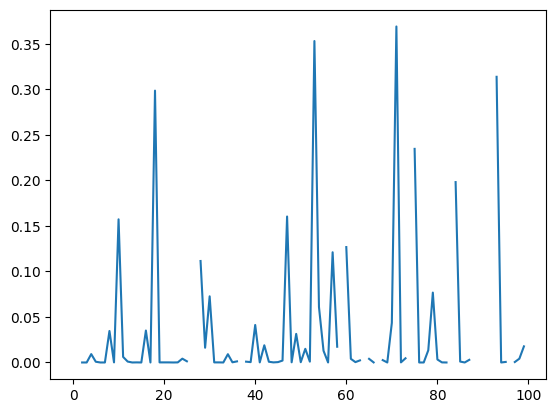

In [ ]:
times_fermat_np = np.array(times_fermat)
plt.plot([i for i in range(len(times_fermat_np))], times_fermat_np)

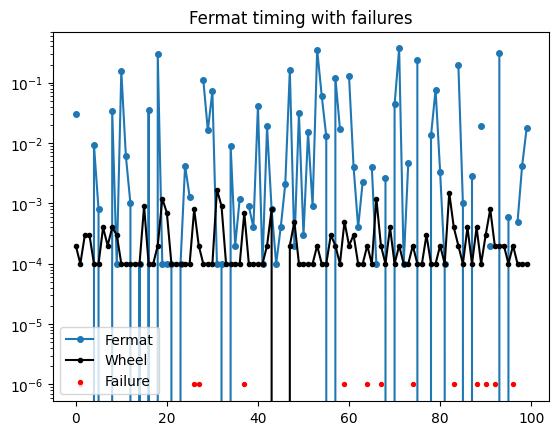

In [ ]:
times_fermat_np = np.array([
    t if t is not None else np.nan
    for t in times_fermat
], dtype=float)

x = np.arange(len(times_fermat_np))
eps = 1e-6
plt.plot(x, times_fermat_np, label="Fermat", marker='o', ms = 4)
plt.plot(x, times_wheel, label="Wheel", color = "black", marker='o', ms = 3)

plt.scatter(fail_idx, [eps]*len(fail_idx), color='red', label='Failure', s=8)


plt.legend()
plt.yscale('log')
plt.title("Fermat timing with failures")
plt.show()

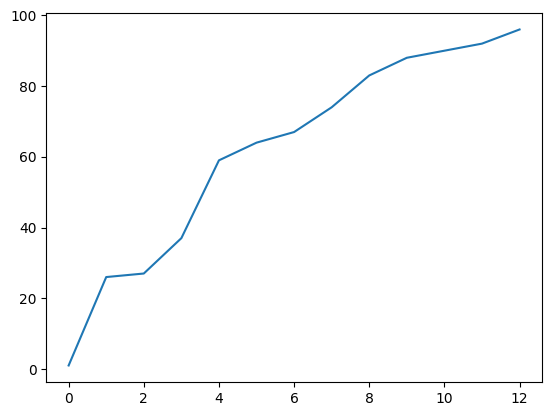

In [ ]:

plt.plot(fail_idx, )